In [1]:
# --------------------------------------------------------------
#  Toyota 5-class CNN
# --------------------------------------------------------------

import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import os

# --------------------------  SEED  ---------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)          # for multi-GPU
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
# --------------------------------------------------------------

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [2]:
# -----------------------  PARAMETERS  ------------------------
BATCH_SIZE       = 32   # batch size
IMAGE_SIZE       = 64   # 64x64 images
BASE_LR          = 1e-3 # base learning rate
WARMPUP_EPOCHS   = 5    # number of warm-up epochs
MIXUP_ALPHA      = 0.2  # mixup alpha parameter
EPOCHS           = 105   # number of training epochs
DATA_ROOT        = "./toyota_intact_dataset"
SELECTED_CLASSES = ["corolla", "camry", "rav4", "highlander", "prius"]
# --------------------------------------------------------------

In [3]:
# ---------------------  DATA PREP  ---------------------------
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.7, 1.0)),
    # transforms.RandomRotation(degrees=10),
    transforms.RandomCrop(IMAGE_SIZE, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# https://docs.pytorch.org/vision/stable/transforms.html#torchvision.transforms.Normalize
# for normalization, we use the standard ImageNet values

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

class FilteredToyotaDataset(Dataset):
    def __init__(self, root, selected, transform=None):
        full = ImageFolder(root)
        self.selected = selected
        self.class_to_idx = {c: i for i, c in enumerate(selected)}
        self.indices = []
        self.old2new = {}
        processed = 0
        
        print("Filtering dataset...")
        for cls in selected:
            old_idx = full.class_to_idx[cls]
            self.old2new[old_idx] = self.class_to_idx[cls]
            class_indices = [i for i, (_, l) in enumerate(full) if l == old_idx]
            self.indices.extend(class_indices)
            processed += len(class_indices)
            print(f"Filtered {len(class_indices)} out of {len(full)} images for class '{cls}' (total processed: {processed})")
        
        self.full = full
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]
        img, old_label = self.full[i]
        new_label = self.old2new[old_label]
        if self.transform:
            img = self.transform(img)
        return img, new_label

# load & split
full_set = FilteredToyotaDataset(DATA_ROOT, SELECTED_CLASSES)
print(f"Selected samples: {len(full_set)}")

train_len = int(0.8 * len(full_set))
val_len   = int(0.1 * len(full_set))
test_len  = len(full_set) - train_len - val_len

train_idx, val_idx, test_idx = random_split(
    range(len(full_set)),
    [train_len, val_len, test_len],
    generator=torch.Generator().manual_seed(SEED)   # reproducible split
)

train_set = Subset(full_set, train_idx)
val_set   = Subset(full_set, val_idx)
test_set  = Subset(full_set, test_idx)

# a tiny helper to apply a transform to a Subset
class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self): return len(self.subset)
    def __getitem__(self, i):
        img, label = self.subset[i]
        if self.transform: img = self.transform(img)
        return img, label

train_set = TransformSubset(train_set, train_transform)
val_set   = TransformSubset(val_set,   test_transform)
test_set  = TransformSubset(test_set,  test_transform)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          generator=torch.Generator().manual_seed(SEED))
dev_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False)
# --------------------------------------------------------------

Filtering dataset...


c:\dev\coding-projects\toyota-cnn-classifier\.venv\Lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Filtered 2300 out of 16641 images for class 'corolla' (total processed: 2300)
Filtered 2247 out of 16641 images for class 'camry' (total processed: 4547)
Filtered 1785 out of 16641 images for class 'rav4' (total processed: 6332)
Filtered 1119 out of 16641 images for class 'highlander' (total processed: 7451)
Filtered 1039 out of 16641 images for class 'prius' (total processed: 8490)
Selected samples: 8490


In [4]:
# --------------------------  MODEL  ---------------------------
class ToyotaCNN_32x32(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.conv1 = nn.Conv2d(3,   64, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(128)
        self.conv3 = nn.Conv2d(128,256, 3, padding=1)
        self.bn3   = nn.BatchNorm2d(256)

        self.pool  = nn.MaxPool2d(2, 2)
        self.drop  = nn.Dropout(0.5)

        self.fc1   = nn.Linear(256*4*4, 512)
        self.bnfc  = nn.BatchNorm1d(512)
        self.fc2   = nn.Linear(512, n_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))   # 32 → 16
        x = self.pool(F.relu(self.bn2(self.conv2(x))))   # 16 → 8
        x = self.pool(F.relu(self.bn3(self.conv3(x))))   # 8  → 4
        x = x.view(-1, 256*4*4)
        x = self.drop(x)
        x = F.relu(self.bnfc(self.fc1(x)))
        x = self.drop(x)
        x = self.fc2(x)
        return x
    
class ToyotaCNN_64x64(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), # 64x64 -> 32x32
            # Block 2
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), # 32x32 -> 16x16
            # Block 3
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),  # 16 → 8
        )
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 8 * 8, 512), nn.ReLU(), nn.BatchNorm1d(512),
            nn.Dropout(0.3),
            nn.Linear(512, n_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)
# --------------------------------------------------------------

In [5]:
# ---------------------  TRAINING HELPERS  --------------------
def evaluate(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            pred = out.argmax(dim=1)
            correct += (pred == y).sum().item()
            total   += y.size(0)
    return 100.0 * correct / total if total else 0.0

def mixup_data(x, y, alpha=MIXUP_ALPHA):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0))
    mixed_x = lam * x + (1-lam) * x[idx]
    return mixed_x, y, y[idx], lam

def train_one_epoch(epoch, model, loader, crit, opt, scheduler, warmup_epochs=WARMPUP_EPOCHS, base_lr=BASE_LR):
    model.train()
    running_loss = correct = total = 0.0

    # ----- LR warm-up (linear) -----
    if epoch <= warmup_epochs:
        lr = base_lr * epoch / warmup_epochs
        for g in opt.param_groups:
            g['lr'] = lr

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()

        if np.random.rand() < 0.5:  # 50% chance
            x_mix, y_a, y_b, lam = mixup_data(x, y)
            out = model(x_mix)
            loss = lam * crit(out, y_a) + (1 - lam) * crit(out, y_b)
            # No accuracy here, as it's not well-defined with MixUp
        else:
            out = model(x)
            loss = crit(out, y)
            pred = out.argmax(dim=1)
            correct += (pred == y).sum().item()

        loss.backward()
        opt.step()

        running_loss += loss.item()
        total   += y.size(0)

    # ----- Step the cosine scheduler after warm-up -----
    if epoch > warmup_epochs:
        scheduler.step()

    acc = 100.0 * correct / total if total > 0 else 0
    return running_loss / len(loader), acc

def validate(model, loader, crit):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss = crit(out, y)
            running_loss += loss.item()
    return running_loss / len(loader)
# --------------------------------------------------------------

[Epoch 01] train_loss: 1.636 | train_acc: 13.38% | dev_loss: 1.556 | dev_acc: 31.10%
[Epoch 02] train_loss: 1.581 | train_acc: 14.34% | dev_loss: 1.504 | dev_acc: 33.33%
[Epoch 03] train_loss: 1.548 | train_acc: 16.20% | dev_loss: 1.543 | dev_acc: 31.33%
[Epoch 04] train_loss: 1.534 | train_acc: 17.42% | dev_loss: 1.555 | dev_acc: 33.10%
[LR] Current LR: 0.001
[Epoch 05] train_loss: 1.511 | train_acc: 17.02% | dev_loss: 1.489 | dev_acc: 34.63%
[Epoch 06] train_loss: 1.481 | train_acc: 16.86% | dev_loss: 1.504 | dev_acc: 38.16%
[Epoch 07] train_loss: 1.440 | train_acc: 23.82% | dev_loss: 1.518 | dev_acc: 36.98%
[Epoch 08] train_loss: 1.415 | train_acc: 18.48% | dev_loss: 1.346 | dev_acc: 44.17%
[Epoch 09] train_loss: 1.391 | train_acc: 21.89% | dev_loss: 1.296 | dev_acc: 49.47%
[LR] Current LR: 0.0009938441702975688
[Epoch 10] train_loss: 1.479 | train_acc: 17.26% | dev_loss: 1.470 | dev_acc: 35.92%
[Epoch 11] train_loss: 1.452 | train_acc: 17.48% | dev_loss: 1.341 | dev_acc: 44.88%
[Ep

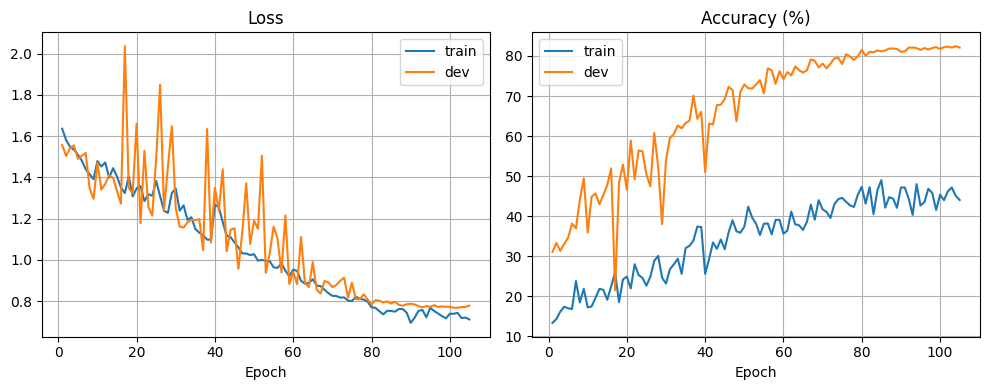


=== FINAL TEST ACCURACY: 80.68% ===


In [7]:
# --------------------------  RUN  ---------------------------
model = ToyotaCNN_64x64(n_classes=len(SELECTED_CLASSES)).to(DEVICE)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=BASE_LR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMPUP_EPOCHS)

history = {"train_loss": [], "train_acc": [], "dev_loss": [], "dev_acc": []}

best_dev = 0
patience = 10
wait = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(
        epoch, model, train_loader, criterion, optimizer,
        scheduler, warmup_epochs=WARMPUP_EPOCHS,
        base_lr=BASE_LR)
    dev_loss = validate(model, dev_loader, criterion)
    dev_acc  = evaluate(model, dev_loader)
    
    if epoch % 5 == 0:
        print("[LR] Current LR:", optimizer.param_groups[0]['lr'])

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["dev_loss"].append(dev_loss)
    history["dev_acc"].append(dev_acc)

    print(f"[Epoch {epoch:02d}] "
          f"train_loss: {tr_loss:.3f} | train_acc: {tr_acc:5.2f}% | "
          f"dev_loss: {dev_loss:.3f} | dev_acc: {dev_acc:5.2f}%")
    
    if dev_acc > best_dev:
        best_dev = dev_acc
        torch.save(model.state_dict(), f'models/best_model_{epoch}.pt')
        wait = 0
    else:
        wait += 1
        if wait >= patience: break

# -----------------------  PLOTS  -------------------------
def plot_history(h):
    ep = range(1, len(h["train_loss"]) + 1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(ep, h["train_loss"], label="train")
    plt.plot(ep, h["dev_loss"],   label="dev")
    plt.title("Loss"); plt.xlabel("Epoch"); plt.legend(); plt.grid()
    plt.subplot(1,2,2)
    plt.plot(ep, h["train_acc"], label="train")
    plt.plot(ep, h["dev_acc"],   label="dev")
    plt.title("Accuracy (%)"); plt.xlabel("Epoch"); plt.legend(); plt.grid()
    plt.tight_layout(); plt.show()

plot_history(history)

# ---------------------  FINAL TEST  ----------------------
test_acc = evaluate(model, test_loader)
print(f"\n=== FINAL TEST ACCURACY: {test_acc:.2f}% ===")
# --------------------------------------------------------------


In [ ]:
# (optional) save best model
if dev_acc > max(history["dev_acc"][:-1] or [0]):
    torch.save(model.state_dict(), "models/best_cnn_warmup_cosine.pt")